# Modelos Avanzados, Feature Engineering y Ensamblado

Este cuaderno implementa mejoras sustanciales sobre los datos y los algoritmos para reducir aún más el error de predicción. Se incluyen:
- **Feature Engineering Complejo:** Variables de `Area`, medias exponenciales (EMA), rezagos estacionales y ventanas móviles de volatilidad.
- **GridSearchCV:** Búsqueda automática de parámetros óptimos.
- **Nuevos Modelos:** HistGradientBoosting (alternativa nativa de Scikit-Learn a LightGBM) y Ensemble (Meta-modelo).

## 1. Carga de Librerías y Datos

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, VotingRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [12]:
file_path = '../data/raw/db_trunc_until_202508_extended_v2.csv'
df = pd.read_csv(file_path)

In [13]:
print(df.info())
print(f"\n{df.head()}")

<class 'pandas.DataFrame'>
RangeIndex: 8778 entries, 0 to 8777
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Description  8778 non-null   str    
 1   Date         8778 non-null   str    
 2   Amount       8778 non-null   float64
 3   Area         8778 non-null   str    
 4   Type         8778 non-null   str    
dtypes: float64(1), str(4)
memory usage: 343.0 KB
None

          Description        Date  Amount                Area      Type
0        Pequeño ocio  2025-08-29    3.94             Leisure  Expenses
1     Pequeño ingreso  2025-08-22    5.00             Deposit    Income
2  Viaje o vacaciones  2025-08-19  679.32  Leisure, Vacations  Expenses
3     Pequeño ingreso  2025-08-18  100.00             Deposit    Income
4      Actividad ocio  2025-08-10   56.60             Leisure  Expenses


In [14]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month_End'] = df['Date'].dt.to_period('M').dt.to_timestamp('M')

## 2. Preprocesamiento y Feature Engineering Avanzado

In [15]:
# 2.1 Agrupación de Gastos Mensuales por Categoría (Area)
# Esto nos dirá cuánto se gastó en Comida, Ocio, Facturas, etc., el mes anterior.
area_monthly = df[df['Type'] == 'Expenses'].groupby(['Month_End', 'Area'])['Amount'].sum().unstack(fill_value=0)

# 2.2 Agrupación General (Income y Expenses)
monthly = df.groupby(['Month_End', 'Type'])['Amount'].sum().unstack(fill_value=0).reset_index()
if 'Expenses' not in monthly.columns: monthly['Expenses'] = 0
if 'Income' not in monthly.columns: monthly['Income'] = 0

# Fusionar con las Áreas de Gasto
ts_df = monthly.set_index('Month_End').join(area_monthly, how='left').fillna(0).sort_index()
ts_df.index.freq = 'ME'

# 2.3 Variables Temporales
df_features = ts_df.copy()
df_features['Month'] = df_features.index.month
df_features['Quarter'] = df_features.index.quarter
df_features['Is_Summer'] = df_features['Month'].isin([6, 7, 8, 9]).astype(int)

# 2.4 Lags y Variables Rodantes Aumentadas
# Lags directos de 1 a 3 meses y estacional de 12 meses (donde haya datos)
for lag in [1, 2, 3, 12]:
    df_features[f'Expenses_Lag_{lag}'] = df_features['Expenses'].shift(lag)
    df_features[f'Income_Lag_{lag}'] = df_features['Income'].shift(lag)

# Medias Móviles y Volatilidad (Desviación Estándar)
df_features['Expenses_Rolling_3_Mean'] = df_features['Expenses'].shift(1).rolling(window=3).mean()
df_features['Expenses_Rolling_3_Std'] = df_features['Expenses'].shift(1).rolling(window=3).std()
df_features['Expenses_Rolling_6_Mean'] = df_features['Expenses'].shift(1).rolling(window=6).mean()

# Medias Móviles Exponenciales (EMA) (Da más peso a los meses recientes)
df_features['Expenses_EMA_3'] = df_features['Expenses'].shift(1).ewm(span=3, adjust=False).mean()

# Mover las categorías de área un paso atrás (Queremos predecir este mes usando el área del mes pasado)
for area_col in area_monthly.columns:
    df_features[f'{area_col}_Lag_1'] = df_features[area_col].shift(1)

df_features = df_features.drop(columns=area_monthly.columns) # Quitar el presente para no hacer trampa

# Limpieza final
df_features = df_features.bfill() # Llenar los primeros meses sin histórico con los valores más cercanos
df_features['Expenses_Rolling_3_Std'] = df_features['Expenses_Rolling_3_Std'].fillna(0)

print("Variables generadas:")
print(df_features.columns.tolist())

Variables generadas:
['Expenses', 'Income', 'Month', 'Quarter', 'Is_Summer', 'Expenses_Lag_1', 'Income_Lag_1', 'Expenses_Lag_2', 'Income_Lag_2', 'Expenses_Lag_3', 'Income_Lag_3', 'Expenses_Lag_12', 'Income_Lag_12', 'Expenses_Rolling_3_Mean', 'Expenses_Rolling_3_Std', 'Expenses_Rolling_6_Mean', 'Expenses_EMA_3', 'Food_Lag_1', 'Food, Vacations_Lag_1', 'Investment_Lag_1', 'Invoice_Lag_1', 'Invoice, Vacations_Lag_1', 'Leisure_Lag_1', 'Leisure, Vacations_Lag_1']


## 3. Conformación de Entrenamiento y Test

In [ ]:
TARGET = 'Expenses'
FEATURES = [c for c in df_features.columns if c != TARGET and c != 'Income'] # Income del mes en curso también sería trampa predecirlo

X = df_features[FEATURES]
y = df_features[TARGET]

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
print(f"Entrenamiento: {len(X_train)} meses, Test: {len(X_test)} meses")

Entrenamiento: 404 meses, Test: 102 meses


## 4. Llamada, Tuning y Entrenamiento de Modelos

In [17]:
# Validaciones usando Series Temporales de bloque rodante
tscv = TimeSeriesSplit(n_splits=3)

print("1. Entrenando Random Forest Baseline...")
rf = RandomForestRegressor(random_state=42)
rf_params = {'n_estimators': [100, 200], 'max_depth': [3, 5]}
rf_grid = GridSearchCV(rf, rf_params, cv=tscv, scoring='neg_mean_absolute_error')
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

print("2. Entrenando XGBoost Avanzado (Tuned)...")
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_params = {'n_estimators': [100, 300], 'learning_rate': [0.01, 0.05], 'max_depth': [2, 3], 'subsample': [0.8]}
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=tscv, scoring='neg_mean_absolute_error')
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_

print("3. Entrenando HistGradientBoosting (LightGBM alternativo de sklearn)...")
lgbm_alt = HistGradientBoostingRegressor(random_state=42)
lgbm_params = {'learning_rate': [0.01, 0.05], 'max_iter': [100, 300], 'max_depth': [3, 5]}
lgbm_grid = GridSearchCV(lgbm_alt, lgbm_params, cv=tscv, scoring='neg_mean_absolute_error')
lgbm_grid.fit(X_train, y_train)
lgbm_best = lgbm_grid.best_estimator_

print("4. Entrenando Meta-Modelo / Ensamblado (VotingRegressor)...")
ensemble = VotingRegressor(estimators=[
    ('rf', rf_best),
    ('xgb', xgb_best),
    ('lgbm', lgbm_best)
])
ensemble.fit(X_train, y_train)

print("¡Entrenamiento completado!")

1. Entrenando Random Forest Baseline...
2. Entrenando XGBoost Avanzado (Tuned)...
3. Entrenando HistGradientBoosting (LightGBM alternativo de sklearn)...
4. Entrenando Meta-Modelo / Ensamblado (VotingRegressor)...
¡Entrenamiento completado!


## 5. Test y Evaluación

In [18]:
models = {
    'Random Forest': rf_best,
    'XGBoost Tuned': xgb_best,
    'HistGradientBoost': lgbm_best,
    'Ensamble Multi-Modelo': ensemble
}

results = []
for name, model in models.items():
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results.append({'Modelo': name, 'MAE': mae, 'RMSE': rmse})

df_results = pd.DataFrame(results).sort_values('MAE', ascending=False).reset_index(drop=True)
display(df_results)

,Modelo,MAE,RMSE
0,Random Forest,137.517141,209.932069
1,Ensamble Multi-Modelo,132.406695,203.587761
2,XGBoost Tuned,131.312802,201.456747
3,HistGradientBoost,129.996463,202.062114


## 6. Comparativa Gráfica

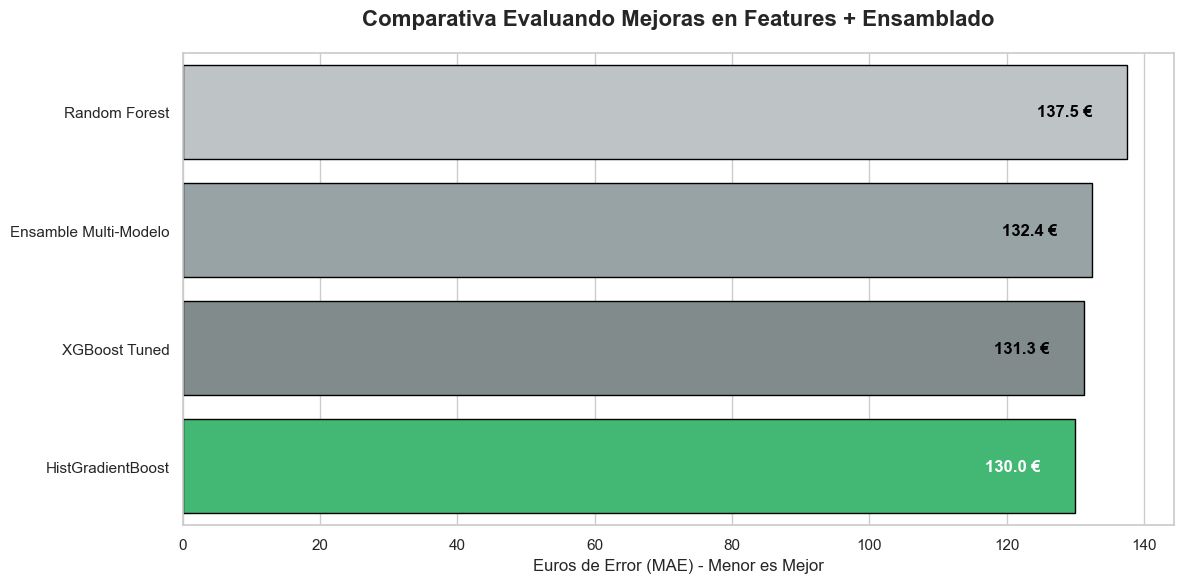

In [19]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

colores = ['#bdc3c7', '#95a5a6', '#7f8c8d', '#2ecc71']
grafico = sns.barplot(x='MAE', y='Modelo', data=df_results, palette=colores, edgecolor='black')

plt.title('Comparativa Evaluando Mejoras en Features + Ensamblado', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Euros de Error (MAE) - Menor es Mejor', fontsize=12)
plt.ylabel('')

for index, value in enumerate(df_results['MAE']):
    grafico.text(value - 5, index, f"{value:.1f} €", color='black' if index != len(df_results)-1 else 'white', 
                 ha="right", va="center", fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()